# Process raw renderings
## Load images

In [10]:
from pathlib import Path

working_dir = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig")

rawRenderings_dir = working_dir / "1_rawRenderings"
cropped_dir = working_dir / "2_cropped"
blue_noise_dir = working_dir / "3_blue_noise"
blue_noise_bin_dir = working_dir / "4_blue_noise_bin"
fast_noise_dir = working_dir / "5_fast_noise"

# Create directories if they don't exist
for directory in [rawRenderings_dir, cropped_dir, blue_noise_dir, blue_noise_bin_dir, fast_noise_dir]:
    directory.mkdir(parents=True, exist_ok=True)

In [11]:
import re
from collections import defaultdict

import numpy as np
import OpenEXR
import Imath

def read_exr_first_channel(path) -> np.ndarray:
    """Read an EXR file and return the first channel as a 2D grayscale array."""
    exr_file = OpenEXR.InputFile(str(path))
    header = exr_file.header()
    dw = header['dataWindow']
    width = dw.max.x - dw.min.x + 1
    height = dw.max.y - dw.min.y + 1
    
    # Get channel names and read the red one
    channels = list(header['channels'].keys())
    first_channel = channels[1]
    
    pt = Imath.PixelType(Imath.PixelType.FLOAT)
    raw_data = exr_file.channel(first_channel, pt)
    arr = np.frombuffer(raw_data, dtype=np.float32).reshape((height, width))
    return arr.astype(np.float64)

pattern = re.compile(r"(\d+)of(\d+)\.exr$", re.IGNORECASE)
groups = defaultdict(list)

for path in sorted(rawRenderings_dir.glob("*.exr")):
    match = pattern.search(path.name)
    if not match:
        continue

    index, total = map(int, match.groups())
    series = path.name[: match.start()]
    arr = read_exr_first_channel(path)
    groups[(series, total)].append((index, path, arr))

grouped_images = {}
for (series, total), items in groups.items():
    items.sort(key=lambda item: item[0])
    grouped_images[series] = {
        "expected_count": total,
        "images": [item[2] for item in items],
        "paths": [item[1] for item in items],
    }

print({series: len(data["images"]) for series, data in grouped_images.items()})

{'bokeh_focus45.0_aperture6_samples167772216_distance250_light': 15}


### Test if renderings were correctly read

Sample series: bokeh_focus45.0_aperture6_samples167772216_distance250_light


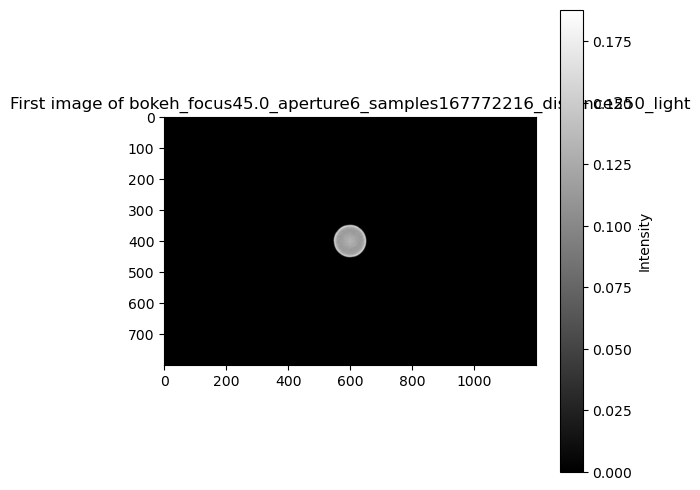

In [12]:
from IPython.display import display
import matplotlib.pyplot as plt

first_series, data = next(iter(grouped_images.items()))
print(f"Sample series: {first_series}")

# Display first image as grayscale
plt.figure(figsize=(6, 6))
plt.imshow(data["images"][0], cmap='gray')
plt.colorbar(label='Intensity')
plt.title(f"First image of {first_series}")
plt.show()

## Determine valid shapes and intensities

In [13]:
import numpy as np
from PIL import Image

LUMINANCE_WEIGHTS = np.array([0.2126, 0.7152, 0.0722], dtype=np.float64)

def _normalize_linear(data: np.ndarray) -> np.ndarray:
    """Scale integer arrays to [0, 1] linear space."""
    if np.issubdtype(data.dtype, np.integer):
        max_val = np.iinfo(data.dtype).max
        if max_val <= 0:
            raise ValueError(f"Non-positive max value for dtype {data.dtype}")
        return data.astype(np.float64) / max_val
    if np.issubdtype(data.dtype, np.floating):
        return data.astype(np.float64)
    raise TypeError(f"Unsupported image dtype: {data.dtype}")

def to_linear_luminance(image) -> np.ndarray:
    """Return a linear [0, 1] luminance array. Accepts PIL Image or numpy array."""
    if isinstance(image, np.ndarray):
        # Already a numpy array (from EXR loading)
        data = image.astype(np.float64)
        if data.ndim == 2:
            return data
        if data.ndim == 3:
            return data[..., 0]  # Take first channel
        raise ValueError(f"Unsupported array shape: {data.shape}")
    
    # PIL Image path
    data = _normalize_linear(np.asarray(image))
    if data.ndim == 2:
        return data
    if data.ndim == 3:
        channels = data.shape[-1]
        if channels == 1:
            return np.squeeze(data, axis=-1)
        if channels == 2:
            return data[..., 0]
        if channels >= 3:
            rgb = data[..., :3]
            return rgb @ LUMINANCE_WEIGHTS
    raise ValueError(f"Unsupported image shape: {data.shape}")

def linear_luminance_to_image(linear: np.ndarray) -> Image.Image:
    """Convert a linear luminance array back to an 8-bit grayscale image."""
    scaled = np.clip(np.rint(linear * 255.0), 0, 255).astype(np.uint8)
    return Image.fromarray(scaled, mode="L")

In [14]:
import numpy as np

intensities = {}
total_shapes = 0
valid_count = 0
skipped_edge = []
skipped_empty = []

for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        total_shapes += 1
        arr = to_linear_luminance(image)
        if not np.any(arr > 0.0):
            skipped_empty.append(path.name)
            continue
        total = float(arr.sum())
        if total <= 0.0:
            skipped_empty.append(path.name)
            continue
        height, width = arr.shape
        nonzero = np.argwhere(arr > 0.0)
        min_y, min_x = nonzero.min(axis=0)
        max_y, max_x = nonzero.max(axis=0)
        if min_x == 0 or min_y == 0 or max_x == width - 1 or max_y == height - 1:
            skipped_edge.append(path.name)
            continue
        valid_count += 1
        intensities[path.name] = total

output_path = cropped_dir / "light_amounts.txt"
output_path.parent.mkdir(parents=True, exist_ok=True)

file_content = f"total {total_shapes}\nvalid {valid_count}\n"
output_path.write_text(file_content, encoding="utf-8")

print(file_content)

total 15
valid 13



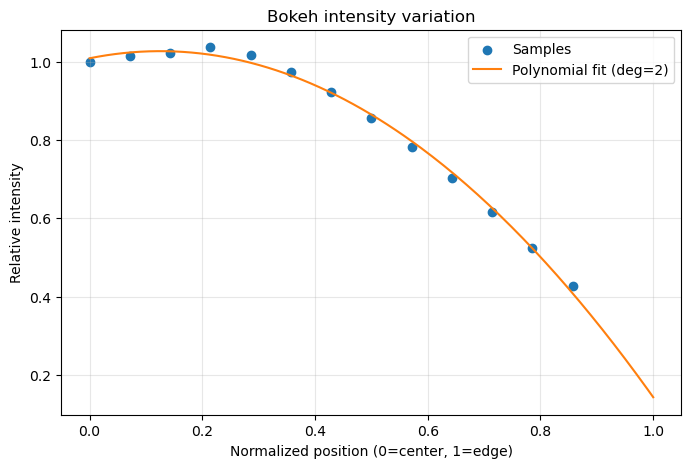

Polynomial coefficients: [-1.15455443  0.28964573  1.00832929]
Function: f(x) = -1.15455 * x^2 + 0.289646 * x + 1.00833


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import re

if not intensities:
    raise RuntimeError("Run the intensity cell first to populate the data.")

# Extract (normalized_index, intensity) pairs from filenames
pattern = re.compile(r"(\d+)of(\d+)", re.IGNORECASE)
samples = []
for name, intensity in intensities.items():
    match = pattern.search(name)
    if not match:
        continue
    index, total = map(int, match.groups())
    normalized_pos = (index - 1) / max(total - 1, 1)
    samples.append((normalized_pos, intensity))

if not samples:
    raise RuntimeError("No valid samples found for curve fitting.")

samples.sort(key=lambda item: item[0])
position_values = np.array([s[0] for s in samples], dtype=np.float64)
intensity_values = np.array([s[1] for s in samples], dtype=np.float64)

# Normalize intensities relative to first sample (position 0)
first_intensity = intensity_values[0]
relative_intensity = intensity_values / first_intensity

# Fit polynomial
poly_degree = 2
poly_coeffs = np.polyfit(position_values, relative_intensity, deg=poly_degree)
fit_grid = np.linspace(0.0, 1.0, num=200)
fit_curve = np.polyval(poly_coeffs, fit_grid)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(position_values, relative_intensity, label="Samples", color="#1f77b4")
plt.plot(fit_grid, fit_curve, label=f"Polynomial fit (deg={poly_degree})", color="#ff7f0e")
plt.xlabel("Normalized position (0=center, 1=edge)")
plt.ylabel("Relative intensity")
plt.title("Bokeh intensity variation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Build function string
powers = np.arange(poly_coeffs.size - 1, -1, -1)
terms = []
for coeff, power in zip(poly_coeffs, powers):
    if abs(coeff) < 1e-12:
        continue
    if power == 0:
        terms.append(f"{coeff:.6g}")
    elif power == 1:
        terms.append(f"{coeff:.6g} * x")
    else:
        terms.append(f"{coeff:.6g} * x^{power}")
function_repr = " + ".join(terms) if terms else "0"

# Append polynomial to the light_amounts file
with output_path.open("a", encoding="utf-8") as f:
    f.write(f"intensity_polynomial {' '.join(f'{c:.6g}' for c in poly_coeffs)}\n")
    f.write(f"intensity_function {function_repr}\n")

print(f"Polynomial coefficients: {poly_coeffs}")
print(f"Function: f(x) = {function_repr}")

### Crop bokeh and save as .pgm

In [16]:
import numpy as np
from pathlib import Path

def save_pgm_ascii(path: Path, data: np.ndarray, max_value: int = 255) -> None:
    array = np.asarray(data)
    if array.ndim != 2:
        raise ValueError("PGM images must be 2D arrays")
    clipped = np.clip(array, 0, max_value).astype(np.uint8)
    height, width = clipped.shape
    header = f"P2\n{width} {height}\n{max_value}\n"
    body = "\n".join(" ".join(str(int(pixel)) for pixel in row) for row in clipped)
    path.write_text(header + body + "\n", encoding="ascii")

Processing 13 valid shapes


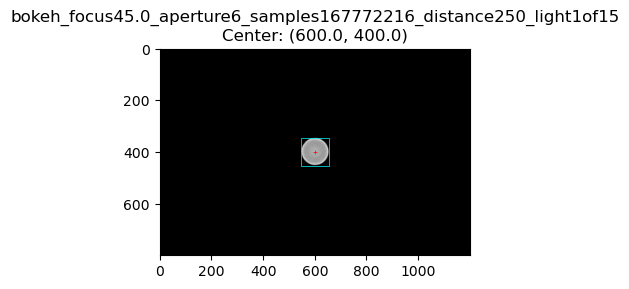

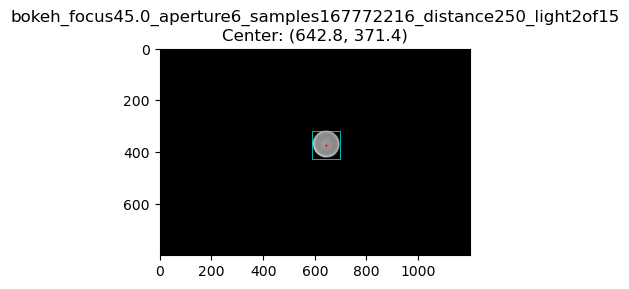

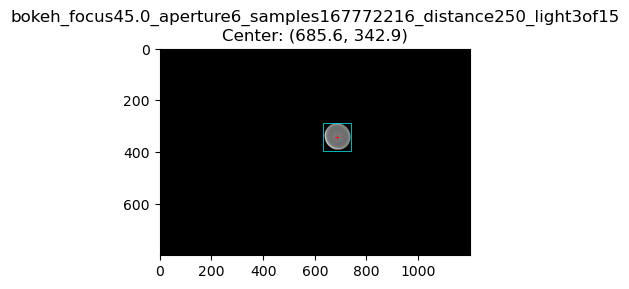

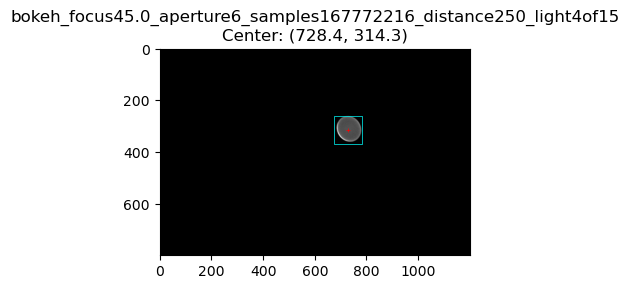

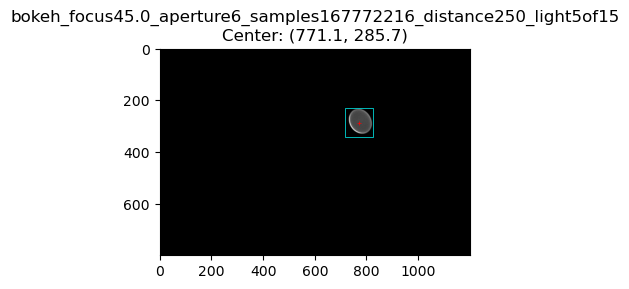

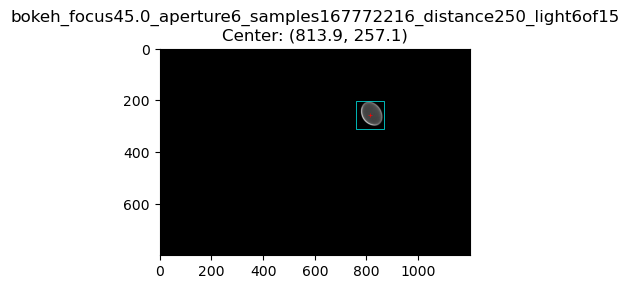

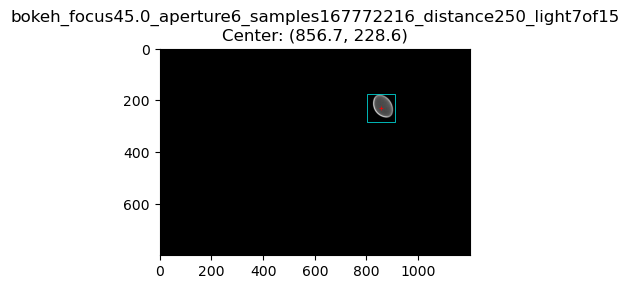

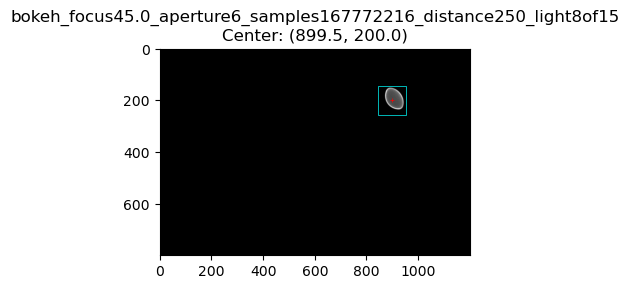

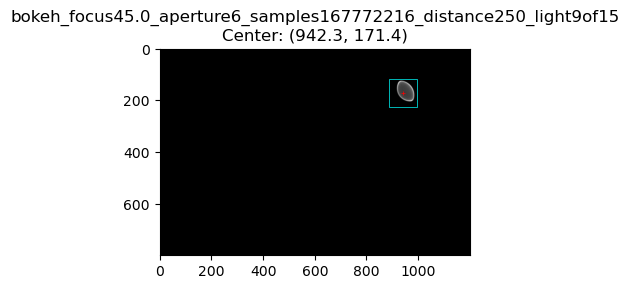

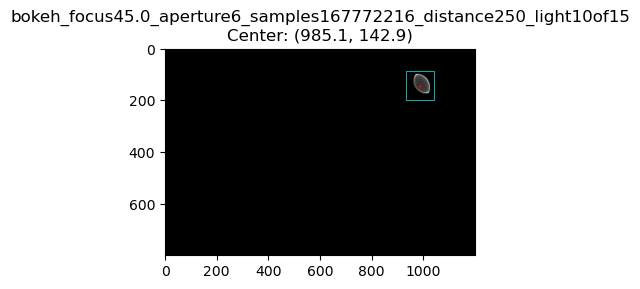

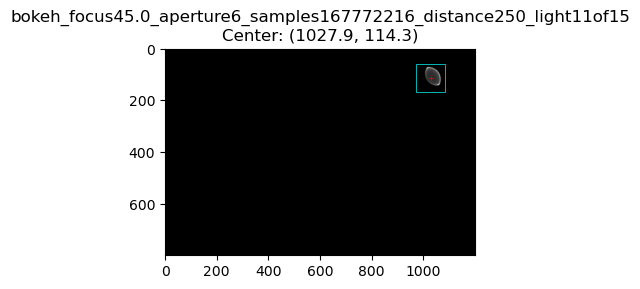

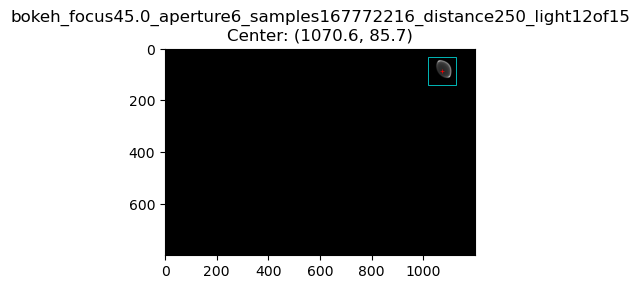

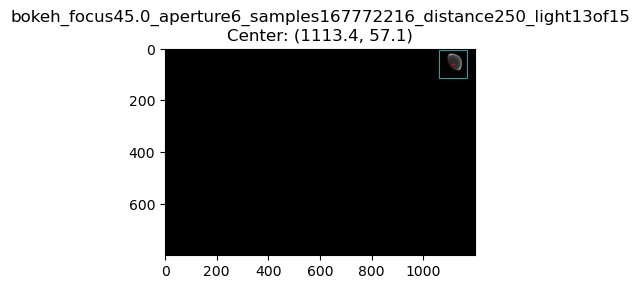

Cropped and saved 13 valid shapes to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\2_cropped


In [17]:
from PIL import ImageOps
from IPython.display import display
import matplotlib.pyplot as plt

def save_exr_single_channel(path, data: np.ndarray) -> None:
    """Save a 2D numpy array as a single-channel EXR file."""
    import OpenEXR
    import Imath
    
    height, width = data.shape
    header = OpenEXR.Header(width, height)
    header['channels'] = {'Y': Imath.Channel(Imath.PixelType(Imath.PixelType.FLOAT))}
    
    exr_file = OpenEXR.OutputFile(str(path), header)
    exr_file.writePixels({'Y': data.astype(np.float32).tobytes()})
    exr_file.close()

cropped_dir.mkdir(parents=True, exist_ok=True)

crop_boxes = {}
reference_side = None

# Collect all valid shapes first to determine count
valid_shapes = []
for data in grouped_images.values():
    for path, image in zip(data["paths"], data["images"]):
        if path.name not in intensities:
            continue
        valid_shapes.append((path, image))

num_shapes = len(valid_shapes)
print(f"Processing {num_shapes} valid shapes")

for idx, (path, image) in enumerate(valid_shapes):
    linear_gray = to_linear_luminance(image)
    gray_image = linear_luminance_to_image(linear_gray)
    
    # Calculate center: equally spaced between image center and upper right corner
    height, width = linear_gray.shape
    img_center_x, img_center_y = width / 2.0, height / 2.0
    upper_right_x, upper_right_y = width - 1, 0
    
    # Interpolate: t=0 is center, t=1 is upper right corner
    if total_shapes > 1:
        t = idx / (total_shapes - 1)
    else:
        t = 0.0
    
    cx = img_center_x + t * (upper_right_x - img_center_x)
    cy = img_center_y + t * (upper_right_y - img_center_y)
    
    # Determine crop size from bounding box
    ys, xs = np.nonzero(linear_gray > 0.0)
    if len(xs) == 0 or len(ys) == 0:
        continue
    side = max(int(round(max(np.ptp(xs), np.ptp(ys))) + 1), 1)
    reference_side = reference_side or side
    side = min(reference_side, linear_gray.shape[0], linear_gray.shape[1])
    
    # Calculate crop box centered on calculated position
    half = side / 2.0
    left, top = int(round(cx - half)), int(round(cy - half))
    right, bottom = left + side, top + side
    
    # Handle padding if crop extends beyond image bounds
    padding = (
        max(0, -left),
        max(0, -top),
        max(0, right - linear_gray.shape[1]),
        max(0, bottom - linear_gray.shape[0]),
    )
    padded = ImageOps.expand(gray_image, border=padding, fill=0) if any(padding) else gray_image
    box = (
        left + padding[0],
        top + padding[1],
        right + padding[0],
        bottom + padding[1],
    )
    crop_boxes[path] = (padding, box)
    cropped = padded.crop(box)
    inverted = ImageOps.invert(cropped)
    
    # Display preview with center marker
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(np.asarray(gray_image), cmap='gray')
    ax.scatter([cx], [cy], c='red', s=10, marker='+', linewidths=0.5)
    ax.set_title(f"{path.stem}\nCenter: ({cx:.1f}, {cy:.1f})")
    rect = plt.Rectangle((left, top), side, side, fill=False, edgecolor='cyan', linewidth=0.5)
    ax.add_patch(rect)
    plt.show()
    
    # Save as PGM (inverted), PNG (normal), and EXR (single channel)
    save_pgm_ascii(cropped_dir / f"{path.stem}.pgm", np.asarray(inverted))
    cropped.save(cropped_dir / f"{path.stem}.png", format="PNG")
    
    # Save cropped as EXR (normalized linear data)
    cropped_linear = np.asarray(cropped).astype(np.float64) / 255.0
    save_exr_single_channel(cropped_dir / f"{path.stem}.exr", cropped_linear)

print(f"Cropped and saved {len(crop_boxes)} valid shapes to {cropped_dir}")

### Generate batch scripts to generate noise for the first shape

In [22]:
bat_path = working_dir / "3_generate_noise.bat"
fastnoise_root = working_dir.parent.parent / "fastnoise"

pattern = re.compile(r"(\d+)of(\d+)", re.IGNORECASE)
pgm_files = list(cropped_dir.glob("*.pgm"))

def numeric_index(p):
    m = pattern.search(p.name)
    return int(m.group(1)) if m else float('inf')

pgm_files.sort(key=numeric_index)
if not pgm_files:
    print("No PGM files found in cropped_dir")
else:
    first_pgm = pgm_files[0]
    input_stem = first_pgm.stem
    output_name = "base_bokeh"
    
    lines = [
        "echo Step 1: Generating blue noise...",
        f"for /l %%x in (0, 1, 31) do ..\\Utils\\agbn\\agbn.exe -F 0 {cropped_dir / input_stem}.pgm 16384 1000 {blue_noise_dir / output_name}_%%x.txt {blue_noise_dir / output_name}_%%x.png",
        "",
        "echo Step 2: Packing blue noise to bin...",
        f"..\\Utils\\Gbn2Bin\\x64\\Release\\Gbn2Bin.exe {blue_noise_dir / output_name}_ {blue_noise_bin_dir / output_name}",
        "",
        "echo Step 3: Running FastNoise...",
        f"pushd \"{fastnoise_root}\"",
        (
            "FastNoise.exe Vector2 Uniform gauss 1.0 exponential 0.1 0.1 separate "
            f"0.5 128 128 32 {output_name} -split -init \"{blue_noise_bin_dir / output_name}.bin\" -progress 1"
        ),
        f"for %%f in (\"{output_name}*\") do move /Y \"%%f\" \"{fast_noise_dir}\"",
        "popd",
        "",
        "echo Done!",
        "pause",
    ]
    
    bat_path.write_text("\n".join(lines), encoding="utf-8")
    print(f"Wrote all commands to {bat_path}")

Wrote all commands to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\3_generate_noise.bat
